In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# ---------------------------------------------------------
# 1. Load Data
# ---------------------------------------------------------
# Ensure 'diabetesafterpre.csv' is in the same directory as this script
file_path = 'diabetesafterpre.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded '{file_path}'")
    print(f"Dataset Shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
    print("Please make sure the CSV file is in the same folder as this script.")
    exit()

# ---------------------------------------------------------
# 2. Prepare Data (X and y)
# ---------------------------------------------------------
target_col = 'class'

# Verify target column exists
if target_col not in df.columns:
    print(f"Error: Column '{target_col}' not found in dataset.")
    exit()

X = df.drop(columns=[target_col])
y = df[target_col]

# Split into Train and Test sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features (Essential for KNN and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data splitting and scaling complete.")

# =========================================================
# MODEL 1: LOGISTIC REGRESSION
# =========================================================
print("\n" + "="*40)
print("LOGISTIC REGRESSION")
print("="*40)

lr = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)

# --- A. Grid Search (Exhaustive) ---
print("Running Grid Search for Logistic Regression...")
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)

print(f"Best Grid Params: {grid_lr.best_params_}")
print(f"Best Grid Accuracy: {grid_lr.best_score_:.4f}")

# --- B. Random Search (Stochastic) ---
print("\nRunning Random Search for Logistic Regression...")
param_dist_lr = {
    'C': np.logspace(-4, 4, 20),
    'penalty': ['l1', 'l2']
}
rand_lr = RandomizedSearchCV(lr, param_dist_lr, n_iter=10, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
rand_lr.fit(X_train_scaled, y_train)

print(f"Best Random Params: {rand_lr.best_params_}")
print(f"Best Random Accuracy: {rand_lr.best_score_:.4f}")


# =========================================================
# MODEL 2: K-NEAREST NEIGHBORS (KNN)
# =========================================================
print("\n" + "="*40)
print("K-NEAREST NEIGHBORS (KNN)")
print("="*40)

knn = KNeighborsClassifier()

# --- A. Grid Search (Exhaustive) ---
print("Running Grid Search for KNN...")
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train)

print(f"Best Grid Params: {grid_knn.best_params_}")
print(f"Best Grid Accuracy: {grid_knn.best_score_:.4f}")

# --- B. Random Search (Stochastic) ---
print("\nRunning Random Search for KNN...")
param_dist_knn = {
    'n_neighbors': range(1, 30),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
rand_knn = RandomizedSearchCV(knn, param_dist_knn, n_iter=15, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
rand_knn.fit(X_train_scaled, y_train)

print(f"Best Random Params: {rand_knn.best_params_}")
print(f"Best Random Accuracy: {rand_knn.best_score_:.4f}")

# =========================================================
# FINAL EVALUATION ON TEST SET
# =========================================================
print("\n" + "="*40)
print("FINAL TEST SET EVALUATION (Using Best Grid Models)")
print("="*40)

# Evaluate Best Logistic Regression Model
best_lr_model = grid_lr.best_estimator_
y_pred_lr = best_lr_model.predict(X_test_scaled)
print("\n--- Logistic Regression Test Report ---")
print(classification_report(y_test, y_pred_lr))

# Evaluate Best KNN Model
best_knn_model = grid_knn.best_estimator_
y_pred_knn = best_knn_model.predict(X_test_scaled)
print("\n--- KNN Test Report ---")
print(classification_report(y_test, y_pred_knn))

Successfully loaded 'diabetesafterpre.csv'
Dataset Shape: (206, 17)
Data splitting and scaling complete.

LOGISTIC REGRESSION
Running Grid Search for Logistic Regression...
Best Grid Params: {'C': 100, 'penalty': 'l1'}
Best Grid Accuracy: 0.9148

Running Random Search for Logistic Regression...
Best Random Params: {'penalty': 'l2', 'C': np.float64(3792.690190732246)}
Best Random Accuracy: 0.9148

K-NEAREST NEIGHBORS (KNN)
Running Grid Search for KNN...
Best Grid Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best Grid Accuracy: 0.8966

Running Random Search for KNN...
Best Random Params: {'weights': 'distance', 'n_neighbors': 6, 'metric': 'minkowski'}
Best Random Accuracy: 0.8966

FINAL TEST SET EVALUATION (Using Best Grid Models)

--- Logistic Regression Test Report ---
              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82        17
         1.0       0.88      0.88      0.88        25

    accuracy                

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, display_html
import seaborn as sns

In [33]:
from pandas import read_csv
data = pd.read_csv('diabetesafterpre.csv')

In [34]:
data

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,0.608696,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1,0.362319,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0
2,0.420290,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.594203,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4,0.724638,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,0.550725,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
202,0.333333,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
203,0.463768,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
204,0.231884,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.metrics import accuracy_score

data = pd.read_csv('diabetesafterpre.csv')

X = data.drop(columns=['class'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_features = SelectKBest(score_func=mutual_info_classif, k='all')
best_features.fit(X_train, y_train)
scores = best_features.scores_

threshold = np.median(scores)
selected_features_filter = [feature for score, feature in zip(scores, X.columns) if score >= threshold]
print(f"Selected features (Filter-Based): {selected_features_filter}")

X_train_filter = X_train[selected_features_filter]
X_test_filter = X_test[selected_features_filter]

model = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=model)
rfe.fit(X_train, y_train)
selected_features_wrapper = X_train.columns[rfe.support_].tolist()
print(f"Selected features (Wrapper-Based): {selected_features_wrapper}")

X_train_wrapper = X_train[selected_features_wrapper]
X_test_wrapper = X_test[selected_features_wrapper]

model.fit(X_train_filter, y_train)
y_pred_filter = model.predict(X_test_filter)
accuracy_filter = accuracy_score(y_test, y_pred_filter)
print(f"Accuracy with Filter-Based Features: {accuracy_filter}")

model.fit(X_train_wrapper, y_train)
y_pred_wrapper = model.predict(X_test_wrapper)
accuracy_wrapper = accuracy_score(y_test, y_pred_wrapper)
print(f"Accuracy with Wrapper-Based Features: {accuracy_wrapper}")

Selected features (Filter-Based): ['Polyuria', 'Polydipsia', 'sudden weight loss', 'Polyphagia', 'visual blurring', 'Itching', 'partial paresis', 'Alopecia']
Selected features (Wrapper-Based): ['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'Itching', 'partial paresis', 'Alopecia']
Accuracy with Filter-Based Features: 0.8571428571428571
Accuracy with Wrapper-Based Features: 0.8809523809523809


In [36]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)
X_train.shape

(164, 16)

In [37]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier

clf_rf_4 = RandomForestClassifier(random_state=42)
rfecv = RFECV(estimator=clf_rf_4, step=1, cv=10,scoring='accuracy')
rfecv = rfecv.fit(X_train, y_train)

print('Optimal number of features :', rfecv.n_features_)

original_feature_names = X.columns

print('Best features :', list(original_feature_names[rfecv.support_]))

Optimal number of features : 15
Best features : ['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia']


In [38]:
data.drop('Obesity',axis = 1,inplace = True)

In [39]:
data.shape

(206, 16)

In [40]:
data.to_csv("diabetesafterdropping.csv", index = False)

In [41]:
data = pd.read_csv('diabetesafterdropping.csv')

In [42]:
X1 = data.drop(columns=['class'])
y1 = data['class']

In [43]:
X_train,X_test,y_train,y_test = train_test_split(X1,y1,test_size = 0.2,random_state=42)
X_train.shape

(164, 15)

In [44]:
X_test.shape

(42, 15)

In [45]:
y_train.shape

(164,)

In [46]:
y_test.shape

(42,)

In [47]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression()
lg.fit(X_train,y_train)

LogisticRegression()

In [48]:
y_pred = lg.predict(X_test)

In [49]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[14  3]
 [ 3 22]]
              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82        17
         1.0       0.88      0.88      0.88        25

    accuracy                           0.86        42
   macro avg       0.85      0.85      0.85        42
weighted avg       0.86      0.86      0.86        42



In [50]:
%matplotlib inline

In [51]:
cmlg=confusion_matrix(y_test, y_pred)

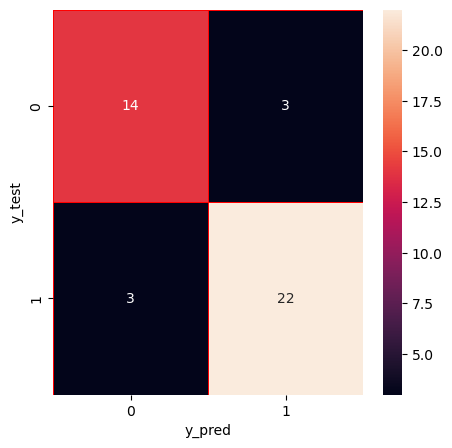

In [52]:
f, ax=plt.subplots(figsize=(5,5))
sns.heatmap(cmlg,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_test")
plt.show()

In [53]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression(C=1.0, penalty='l2', solver='liblinear', class_weight='balanced', max_iter=500)
lg.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=500, solver='liblinear')

In [54]:
y_pred = lg.predict(X_test)

In [55]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[15  2]
 [ 4 21]]
              precision    recall  f1-score   support

         0.0       0.79      0.88      0.83        17
         1.0       0.91      0.84      0.88        25

    accuracy                           0.86        42
   macro avg       0.85      0.86      0.85        42
weighted avg       0.86      0.86      0.86        42



In [56]:
cmlg=confusion_matrix(y_test, y_pred)

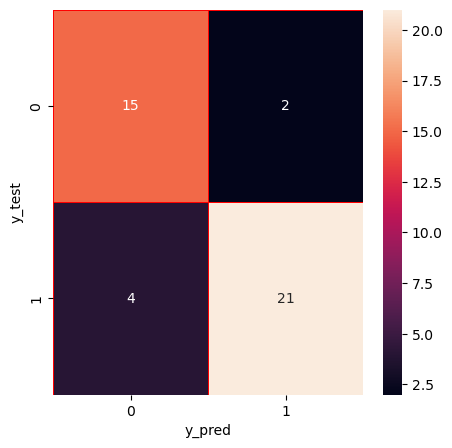

In [57]:
f, ax=plt.subplots(figsize=(5,5))
sns.heatmap(cmlg,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_test")
plt.show()

In [58]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=1)
classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [59]:
y_pred = classifier.predict(X_test)

In [60]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[17  0]
 [ 2 23]]
              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94        17
         1.0       1.00      0.92      0.96        25

    accuracy                           0.95        42
   macro avg       0.95      0.96      0.95        42
weighted avg       0.96      0.95      0.95        42



In [61]:
cmknn=confusion_matrix(y_test, y_pred)

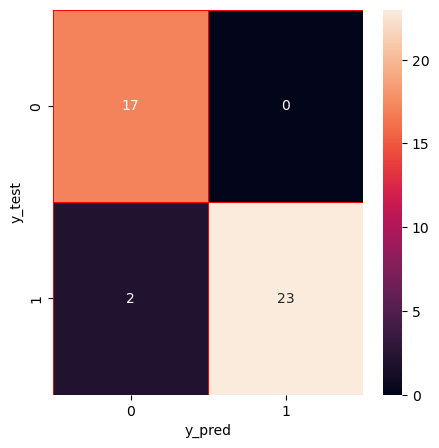

In [62]:
f, ax=plt.subplots(figsize=(5,5))
sns.heatmap(cmknn,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_test")
plt.show()

In [63]:
from sklearn import svm
svm_classifier = svm.SVC(kernel='linear')
svm_classifier.fit(X_train, y_train)

SVC(kernel='linear')

In [64]:
y_predict = svm_classifier.predict(X_test)

In [65]:
print(confusion_matrix(y_test, y_predict))
print(classification_report(y_test, y_predict))

[[14  3]
 [ 3 22]]
              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82        17
         1.0       0.88      0.88      0.88        25

    accuracy                           0.86        42
   macro avg       0.85      0.85      0.85        42
weighted avg       0.86      0.86      0.86        42



In [66]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(svm.SVC(), param_grid, cv=5, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [67]:
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test)

print("Best Model Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Best Model Classification Report:\n", classification_report(y_test, y_pred_best))

Best Model Confusion Matrix:
 [[15  2]
 [ 3 22]]
Best Model Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.88      0.86        17
         1.0       0.92      0.88      0.90        25

    accuracy                           0.88        42
   macro avg       0.88      0.88      0.88        42
weighted avg       0.88      0.88      0.88        42



In [74]:
import sys
!{sys.executable} -m pip install scipy

Defaulting to user installation because normal site-packages is not writeable


In [75]:
param_dist = {
    'C': uniform(0.1, 100),
    'gamma': uniform(0.001, 1),
    'kernel': ['rbf', 'linear']
}

random_search = RandomizedSearchCV(svm.SVC(), param_distributions=param_dist, n_iter=10, cv=5, verbose=2, n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': np.float64(0.8066305219717406), 'gamma': np.float64(0.024062425041415758), 'kernel': 'rbf'}


In [76]:
best_svm = random_search.best_estimator_
y_pred_best = best_svm.predict(X_test)

print("Best Model Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Best Model Classification Report:\n", classification_report(y_test, y_pred_best))

Best Model Confusion Matrix:
 [[15  2]
 [ 4 21]]
Best Model Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      0.88      0.83        17
         1.0       0.91      0.84      0.88        25

    accuracy                           0.86        42
   macro avg       0.85      0.86      0.85        42
weighted avg       0.86      0.86      0.86        42



In [77]:
from sklearn import svm
svm_classifier = svm.SVC(kernel='rbf')
svm_classifier.fit(X_train, y_train)

SVC()

In [78]:
y_predict = svm_classifier.predict(X_test)

In [79]:
print(confusion_matrix(y_test, y_predict))
print(classification_report(y_test, y_predict))

[[15  2]
 [ 3 22]]
              precision    recall  f1-score   support

         0.0       0.83      0.88      0.86        17
         1.0       0.92      0.88      0.90        25

    accuracy                           0.88        42
   macro avg       0.88      0.88      0.88        42
weighted avg       0.88      0.88      0.88        42

